In [67]:
# ============================================
# LAB 03 - EDGE DETECTION AND CLASSIFICATION
# Google Colab + Google Drive
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# --------------------------------------------
# Mount Google Drive
# --------------------------------------------

from google.colab import drive

drive.mount('/content/drive')


# --------------------------------------------
# Dataset Configuration
# --------------------------------------------

DATASET_PATH = (
    "/content/drive/MyDrive/datasets/"
    "Skin cancer ISIC The International Skin "
    "Imaging Collaboration"
)

TRAIN_PATH = os.path.join(
    DATASET_PATH,
    "Train"
)

TEST_PATH = os.path.join(
    DATASET_PATH,
    "Test"
)

IMG_SIZE = (128, 128)


# --------------------------------------------
# Check Dataset Paths
# --------------------------------------------

print("Dataset path:")
print(DATASET_PATH)

print("\nTrain path:")
print(TRAIN_PATH)

print("\nTest path:")
print(TEST_PATH)

print("\nTrain folder exists:", os.path.exists(TRAIN_PATH))
print("Test folder exists:", os.path.exists(TEST_PATH))


# --------------------------------------------
# Get Class Names Automatically
# --------------------------------------------

CLASSES = sorted([
    folder_name
    for folder_name in os.listdir(TRAIN_PATH)
    if os.path.isdir(
        os.path.join(TRAIN_PATH, folder_name)
    )
])

print("\nClasses found:")

for i, class_name in enumerate(CLASSES):
    print(f"{i}: {class_name}")

print("\nTotal number of classes:", len(CLASSES))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path:
/content/drive/MyDrive/datasets/Skin cancer ISIC The International Skin Imaging Collaboration

Train path:
/content/drive/MyDrive/datasets/Skin cancer ISIC The International Skin Imaging Collaboration/Train

Test path:
/content/drive/MyDrive/datasets/Skin cancer ISIC The International Skin Imaging Collaboration/Test

Train folder exists: True
Test folder exists: True

Classes found:
0: actinic keratosis
1: basal cell carcinoma
2: dermatofibroma
3: melanoma
4: nevus
5: pigmented benign keratosis
6: seborrheic keratosis
7: squamous cell carcinoma
8: vascular lesion

Total number of classes: 9


In [68]:
# ============================================
# Load Representative Images
# ============================================

def load_sample_images(class_names):
    """
    Load one representative image from each
    selected class in the Test dataset.
    """

    images = []

    for class_name in class_names:

        class_path = os.path.join(
            TEST_PATH,
            class_name
        )

        if not os.path.exists(class_path):
            print(
                f"Warning: Folder not found: {class_path}"
            )
            continue

        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            )
        ]

        if len(image_files) == 0:
            print(
                f"Warning: No images found in {class_path}"
            )
            continue

        # Sort so the same representative image
        # is selected each time
        image_files = sorted(image_files)

        image_path = os.path.join(
            class_path,
            image_files[0]
        )

        img = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            print(
                f"Warning: Could not read {image_path}"
            )
            continue

        img = cv2.resize(
            img,
            IMG_SIZE
        )

        images.append(
            (class_name, img)
        )

    return images


# Three classes required by Task 1
SELECTED_CLASSES = [
    "melanoma",
    "basal cell carcinoma",
    "nevus"
]


sample_images = load_sample_images(
    SELECTED_CLASSES
)


print("\nRepresentative images loaded:")

for class_name, img in sample_images:
    print(
        f"{class_name}: {img.shape}"
    )


Representative images loaded:
melanoma: (128, 128)
basal cell carcinoma: (128, 128)
nevus: (128, 128)


# Task 1: Comparative Edge Detection

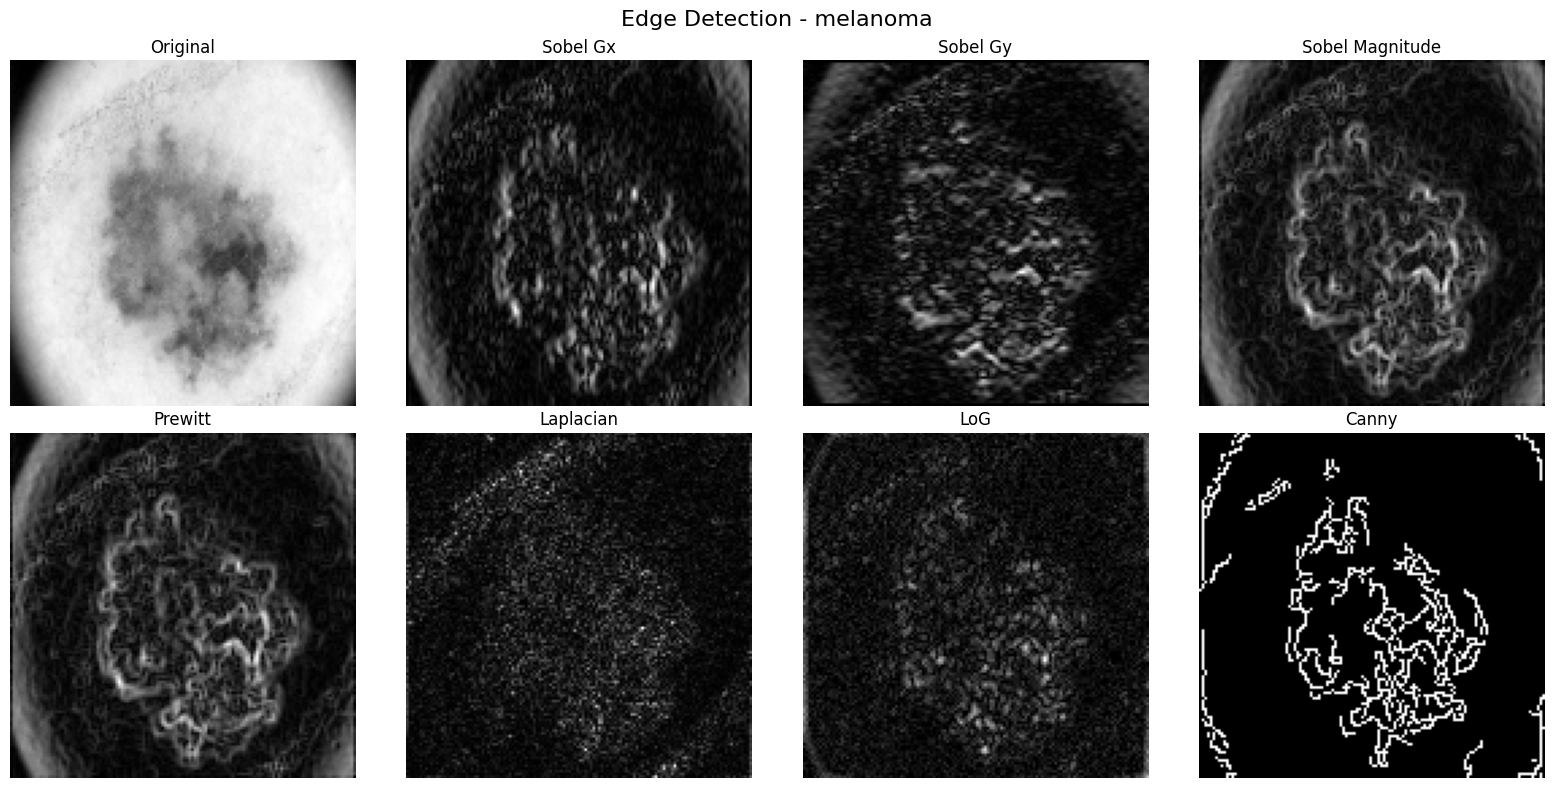

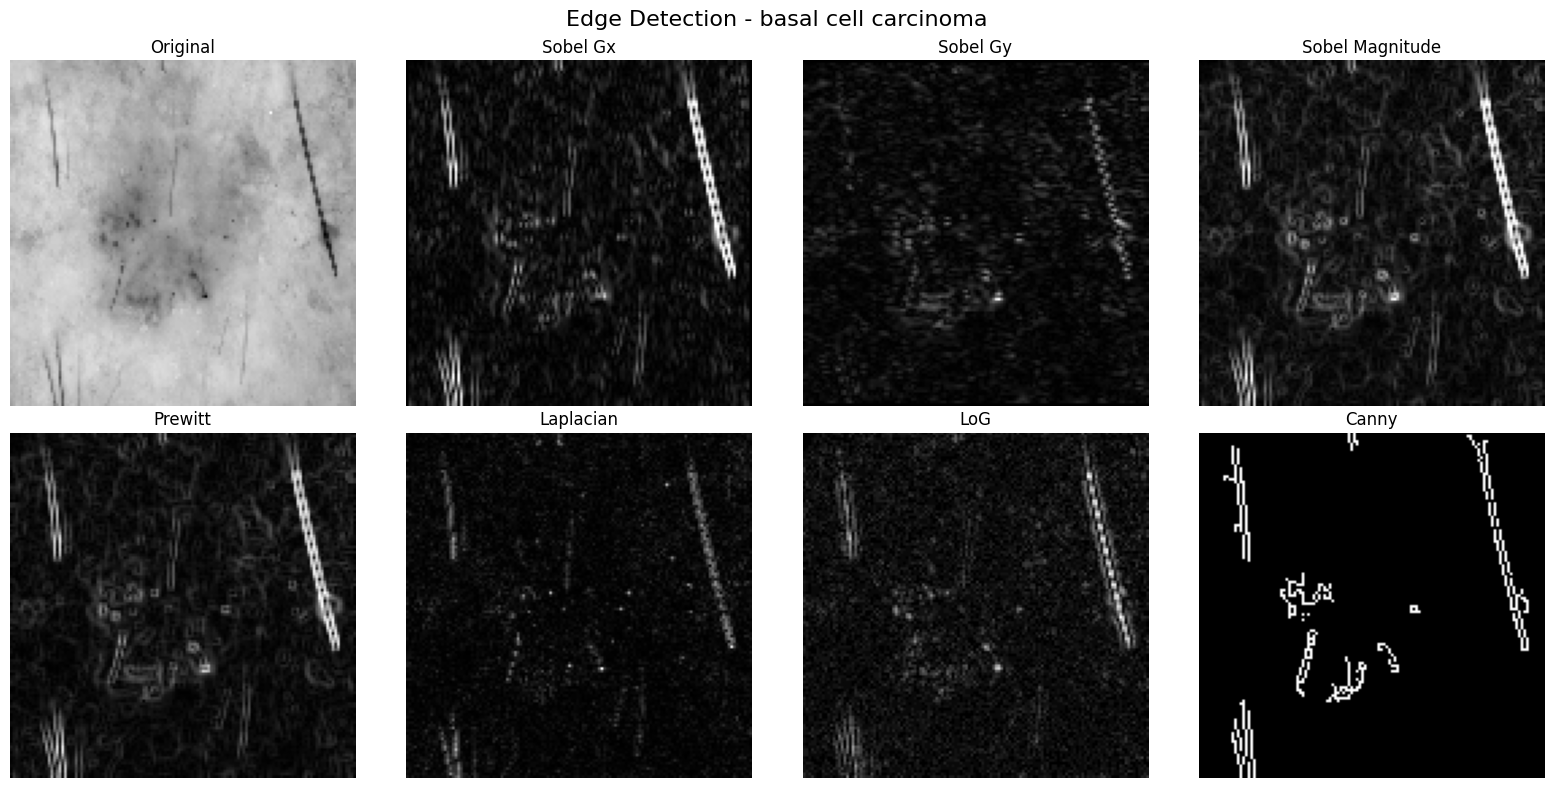

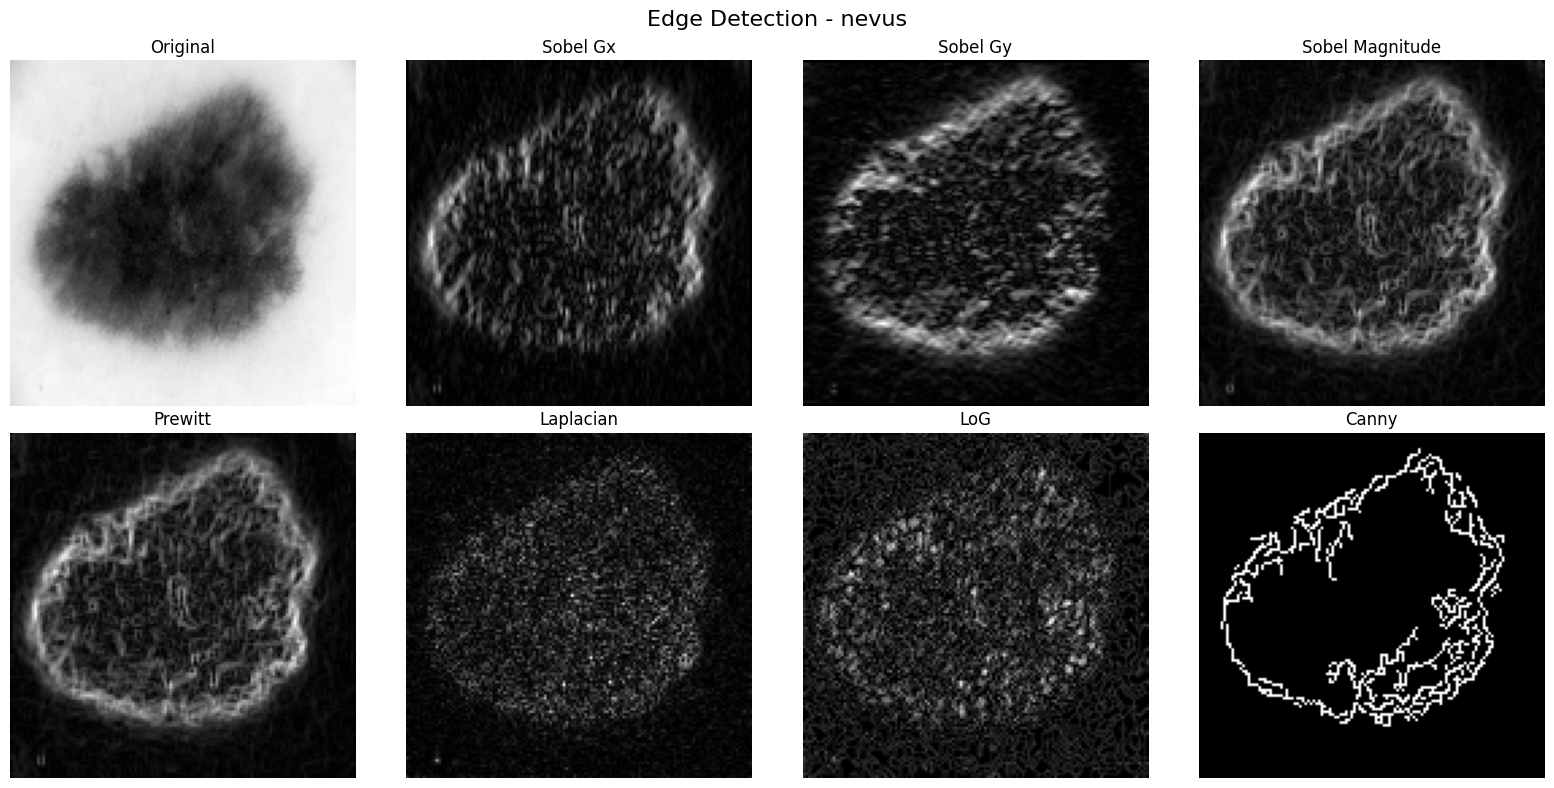

In [69]:
# ============================================
# TASK 1: EDGE DETECTION
# ============================================

def apply_edge_detectors(img):

    # Make sure image is grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )
    else:
        gray = img


    # ----------------------------------------
    # 1. Sobel Gx
    # ----------------------------------------

    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_x = cv2.convertScaleAbs(
        sobel_x
    )


    # ----------------------------------------
    # 2. Sobel Gy
    # ----------------------------------------

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel_y = cv2.convertScaleAbs(
        sobel_y
    )


    # ----------------------------------------
    # 3. Sobel Gradient Magnitude
    # ----------------------------------------

    sobel_x_float = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_y_float = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel_magnitude = np.sqrt(
        sobel_x_float ** 2 +
        sobel_y_float ** 2
    )

    sobel_magnitude = np.uint8(
        np.clip(
            sobel_magnitude,
            0,
            255
        )
    )


    # ----------------------------------------
    # 4. Prewitt
    # ----------------------------------------

    prewitt_x_kernel = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

    prewitt_y_kernel = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32)

    prewitt_x = cv2.filter2D(
        gray,
        cv2.CV_32F,
        prewitt_x_kernel
    )

    prewitt_y = cv2.filter2D(
        gray,
        cv2.CV_32F,
        prewitt_y_kernel
    )

    prewitt_magnitude = np.sqrt(
        prewitt_x ** 2 +
        prewitt_y ** 2
    )

    prewitt = np.uint8(
        np.clip(
            prewitt_magnitude,
            0,
            255
        )
    )


    # ----------------------------------------
    # 5. Laplacian
    # ----------------------------------------

    laplacian = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )

    laplacian = cv2.convertScaleAbs(
        laplacian
    )


    # ----------------------------------------
    # 6. LoG
    # Gaussian Blur + Laplacian
    # ----------------------------------------

    log_blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    log = cv2.Laplacian(
        log_blurred,
        cv2.CV_64F
    )

    log = cv2.convertScaleAbs(
        log
    )


    # ----------------------------------------
    # 7. Canny
    # ----------------------------------------

    canny = cv2.Canny(
        gray,
        50,
        150
    )


    return {
        "Original": gray,
        "Sobel Gx": sobel_x,
        "Sobel Gy": sobel_y,
        "Sobel Magnitude": sobel_magnitude,
        "Prewitt": prewitt,
        "Laplacian": laplacian,
        "LoG": log,
        "Canny": canny
    }


# --------------------------------------------
# Display Results
# --------------------------------------------

for class_name, img in sample_images:

    edges = apply_edge_detectors(img)

    titles = [
        "Original",
        "Sobel Gx",
        "Sobel Gy",
        "Sobel Magnitude",
        "Prewitt",
        "Laplacian",
        "LoG",
        "Canny"
    ]

    plt.figure(figsize=(16, 8))

    for i, title in enumerate(titles):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            edges[title],
            cmap="gray"
        )

        plt.title(title)
        plt.axis("off")

    plt.suptitle(
        f"Edge Detection - {class_name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

# Task 2: Effect of Noise on Edge Detection

In [70]:
# ============================================
# TASK 2: Effect of Noise on Edge Detection
# ============================================
import pandas as pd

def add_gaussian_noise(img):
    row, col = img.shape
    mean = 0
    sigma = 25
    gauss = np.random.normal(mean, sigma, (row, col))
    noisy = np.clip(img + gauss, 0, 255).astype(np.uint8)
    return noisy

def add_salt_pepper_noise(img):
    row, col = img.shape
    s_vs_p = 0.5
    amount = 0.04
    noisy = np.copy(img)
    # Salt
    num_salt = np.ceil(amount * img.size * s_vs_p)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
    noisy[tuple(coords)] = 255
    # Pepper
    num_pepper = np.ceil(amount * img.size * (1. - s_vs_p))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
    noisy[tuple(coords)] = 0
    return noisy

# Analyze noise and filtering on the first representative image
sample_img = sample_images[0][1]
noisy_gauss = add_gaussian_noise(sample_img)
noisy_sp = add_salt_pepper_noise(sample_img)

filtered_gauss = cv2.GaussianBlur(noisy_gauss, (5, 5), 0)
filtered_median = cv2.medianBlur(noisy_sp, 5)

# Build DataFrame for Table 1 (Replace dummy observations with your visual findings for the MD report)
table1_data = [
    {"Edge Detector": "Sobel", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None", "Edge Quality": "High", "Noise Sensitivity": "Moderate", "Observations": "Clear boundaries detected."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "None", "Edge Quality": "Poor", "Noise Sensitivity": "High", "Observations": "Many false edges due to noise."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter", "Edge Quality": "Good", "Noise Sensitivity": "Low", "Observations": "False edges reduced; edges slightly smoothed."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "Median Filter", "Edge Quality": "Good", "Noise Sensitivity": "Low", "Observations": "S&P noise completely removed before edge detection."},
    {"Edge Detector": "Prewitt", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None", "Edge Quality": "High", "Noise Sensitivity": "Moderate", "Observations": "Similar to Sobel but slightly less sensitive."},
    {"Edge Detector": "Laplacian", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None", "Edge Quality": "High", "Noise Sensitivity": "Very High", "Observations": "Catches fine details but amplifies underlying texture noise."},
    {"Edge Detector": "LoG", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Built-in smoothing", "Edge Quality": "Good", "Noise Sensitivity": "Low", "Observations": "Internal Gaussian blur mitigates noise well."},
    {"Edge Detector": "Canny", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None", "Edge Quality": "Excellent", "Noise Sensitivity": "Low", "Observations": "Continuous, thin edges representing structural boundaries."},
]

table1_df = pd.DataFrame(table1_data)
display(table1_df)

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,High,Moderate,Clear boundaries detected.
1,Sobel,Noisy,Gaussian,None,Poor,High,Many false edges due to noise.
2,Sobel,Noisy,Gaussian,Gaussian Filter,Good,Low,False edges reduced; edges slightly smoothed.
3,Sobel,Noisy,Salt & Pepper,Median Filter,Good,Low,S&P noise completely removed before edge detec...
4,Prewitt,Original,None,None,High,Moderate,Similar to Sobel but slightly less sensitive.
5,Laplacian,Original,None,None,High,Very High,Catches fine details but amplifies underlying ...
6,LoG,Noisy,Gaussian,Built-in smoothing,Good,Low,Internal Gaussian blur mitigates noise well.
7,Canny,Original,None,None,Excellent,Low,"Continuous, thin edges representing structural..."


# Task 3: Parameter Analysis of Canny

In [71]:
# ============================================
# TASK 3: Canny Parameter Analysis
# ============================================

canny_configs = [
    {"Configuration": "Canny-1", "Low": 30, "High": 100, "Kernel": "3x3"},
    {"Configuration": "Canny-2", "Low": 50, "High": 150, "Kernel": "3x3"},
    {"Configuration": "Canny-3", "Low": 100, "High": 200, "Kernel": "3x3"},
    {"Configuration": "Canny-4", "Low": 50, "High": 150, "Kernel": "5x5"}
]

table2_data = []
for config in canny_configs:
    # Using Gaussian blur if kernel is 5x5 for Canny-4 simulation
    test_img = sample_img.copy()
    if config["Kernel"] == "5x5":
        test_img = cv2.GaussianBlur(test_img, (5, 5), 0)

    edges = cv2.Canny(test_img, config["Low"], config["High"])
    detected_pixels = np.sum(edges > 0)

    table2_data.append({
        "Configuration": config["Configuration"],
        "Low Threshold": config["Low"],
        "High Threshold": config["High"],
        "Kernel Size": config["Kernel"],
        "Edge Quality": "Modify based on visual inspection",
        "Number of Detected Edges": detected_pixels,
        "Observation": "Modify based on visual inspection"
    })

table2_df = pd.DataFrame(table2_data)
display(table2_df)

# Programmatically selecting the best configuration (Example: Canny-2)
best_canny_cfg = {"low": 50, "high": 150, "ksize": 3}
print(f"\nSelected Best Canny Configuration: Low={best_canny_cfg['low']}, High={best_canny_cfg['high']}, Kernel={best_canny_cfg['ksize']}")

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,Modify based on visual inspection,2691,Modify based on visual inspection
1,Canny-2,50,150,3x3,Modify based on visual inspection,1478,Modify based on visual inspection
2,Canny-3,100,200,3x3,Modify based on visual inspection,432,Modify based on visual inspection
3,Canny-4,50,150,5x5,Modify based on visual inspection,729,Modify based on visual inspection



Selected Best Canny Configuration: Low=50, High=150, Kernel=3



# Task 4 & 5: Dataset Prep & Classification

In [72]:
# ============================================
# TASKS 4 & 5: Dataset Prep & 70/15/15 Stratified Split
# ============================================

max_samples_per_class = 100
X_raw, X_filtered, X_edge, y_labels = [], [], [], []

for label_idx, class_name in enumerate(CLASSES):
    class_path = os.path.join(TRAIN_PATH, class_name)
    if not os.path.exists(class_path): continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:max_samples_per_class]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        img = cv2.resize(img, IMG_SIZE)

        # Representations
        raw = img
        filtered = cv2.GaussianBlur(img, (5, 5), 0) # Assuming Gaussian performed best in Lab 02
        edge = cv2.Canny(filtered, best_canny_cfg['low'], best_canny_cfg['high'])

        X_raw.append(raw)
        X_filtered.append(filtered)
        X_edge.append(edge)
        y_labels.append(label_idx)

X_raw, X_filtered, X_edge = np.array(X_raw), np.array(X_filtered), np.array(X_edge)
y_labels = np.array(y_labels)

# Normalize for CNNs/ML
X_raw = X_raw.astype('float32') / 255.0
X_filtered = X_filtered.astype('float32') / 255.0
X_edge = X_edge.astype('float32') / 255.0

# Stratified Split: 70% Train, 15% Validation, 15% Test
# We split indices to ensure identical sets across Raw, Filtered, and Edge
indices = np.arange(len(y_labels))
train_idx, temp_idx, y_train, y_temp = train_test_split(indices, y_labels, test_size=0.30, stratify=y_labels, random_state=42)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Data Shapes - Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Data Shapes - Train: 610, Val: 131, Test: 131


In [73]:
# ============================================
# TASK 5: Classical Models (SVM, RF, KNN)
# ============================================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def flatten_data(X_data, idx):
    return X_data[idx].reshape(len(idx), -1)

datasets = {
    "Raw": (flatten_data(X_raw, train_idx), flatten_data(X_raw, test_idx)),
    "Filtered": (flatten_data(X_filtered, train_idx), flatten_data(X_filtered, test_idx)),
    "Edge": (flatten_data(X_edge, train_idx), flatten_data(X_edge, test_idx))
}

classical_models = {
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3)
}

results_log = []
predictions_log = {}

for model_name, model in classical_models.items():
    row_data = {"Model": model_name}
    predictions_log[model_name] = {}

    for rep, (X_tr, X_te) in datasets.items():
        t0 = time.time()
        model.fit(X_tr, y_train)
        train_time = time.time() - t0

        t1 = time.time()
        preds = model.predict(X_te)
        inf_time = time.time() - t1

        acc = accuracy_score(y_test, preds)
        row_data[f"Accuracy {rep}"] = acc

        predictions_log[model_name][rep] = preds

        # We record precision, recall, f1, and time for the Edge representation as requested for Table 3
        if rep == "Edge":
            p, r, f, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
            row_data["Precision"] = p
            row_data["Recall"] = r
            row_data["F1"] = f
            row_data["Training Time (s)"] = train_time
            row_data["Inference Time (s)"] = inf_time

    results_log.append(row_data)
    print(f"Completed classical training for: {model_name}")

Completed classical training for: SVM
Completed classical training for: Random Forest
Completed classical training for: KNN


In [74]:
# ============================================
# TASK 5: CNN Models 1 & 2 + Table 3 Generation
# ============================================
from tensorflow.keras.utils import to_categorical

def reshape_cnn(X_data, idx):
    return X_data[idx].reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)

y_train_cnn = to_categorical(y_train, num_classes=len(CLASSES))
y_val_cnn = to_categorical(y_val, num_classes=len(CLASSES))

cnn_datasets = {
    "Raw": (reshape_cnn(X_raw, train_idx), reshape_cnn(X_raw, val_idx), reshape_cnn(X_raw, test_idx)),
    "Filtered": (reshape_cnn(X_filtered, train_idx), reshape_cnn(X_filtered, val_idx), reshape_cnn(X_filtered, test_idx)),
    "Edge": (reshape_cnn(X_edge, train_idx), reshape_cnn(X_edge, val_idx), reshape_cnn(X_edge, test_idx))
}

def get_cnn_model_1():
    model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def get_cnn_model_2():
    model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_architectures = {"CNN Model 1": get_cnn_model_1, "CNN Model 2": get_cnn_model_2}

for model_name, model_fn in cnn_architectures.items():
    row_data = {"Model": model_name}
    predictions_log[model_name] = {}

    for rep, (X_tr, X_v, X_te) in cnn_datasets.items():
        model = model_fn()

        t0 = time.time()
        model.fit(X_tr, y_train_cnn, validation_data=(X_v, y_val_cnn), epochs=5, batch_size=32, verbose=0)
        train_time = time.time() - t0

        t1 = time.time()
        raw_preds = model.predict(X_te, verbose=0)
        inf_time = time.time() - t1

        preds = np.argmax(raw_preds, axis=1)
        acc = accuracy_score(y_test, preds)
        row_data[f"Accuracy {rep}"] = acc
        predictions_log[model_name][rep] = preds

        if rep == "Edge":
            p, r, f, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
            row_data["Precision"] = p
            row_data["Recall"] = r
            row_data["F1"] = f
            row_data["Training Time (s)"] = train_time
            row_data["Inference Time (s)"] = inf_time

    results_log.append(row_data)
    print(f"Completed CNN training for: {model_name}")

# Generate Table 3
table3_df = pd.DataFrame(results_log)
cols = ["Model", "Accuracy Raw", "Accuracy Filtered", "Accuracy Edge", "Precision", "Recall", "F1", "Training Time (s)", "Inference Time (s)"]
table3_df = table3_df[cols]
print("\n--- Table 3: Cross-Lab Classification Performance Comparison ---")
display(table3_df)

Completed CNN training for: CNN Model 1
Completed CNN training for: CNN Model 2

--- Table 3: Cross-Lab Classification Performance Comparison ---


,Model,Accuracy Raw,Accuracy Filtered,Accuracy Edge,Precision,Recall,F1,Training Time (s),Inference Time (s)
0,SVM,0.312977,0.328244,0.198473,0.293850,0.198473,0.156193,5.560903,1.503533
1,Random Forest,0.358779,0.358779,0.198473,0.214755,0.198473,0.180459,1.408581,0.009144
2,KNN,0.351145,0.328244,0.106870,0.012427,0.106870,0.022265,0.004377,0.142217
3,CNN Model 1,0.114504,0.114504,0.198473,0.171954,0.198473,0.175256,6.056819,1.361165
4,CNN Model 2,0.114504,0.213740,0.221374,0.197346,0.221374,0.196977,9.359626,0.677951


# Task 6: Visual Comparison of Classification Results

Best Performing Model Identified: CNN Model 2


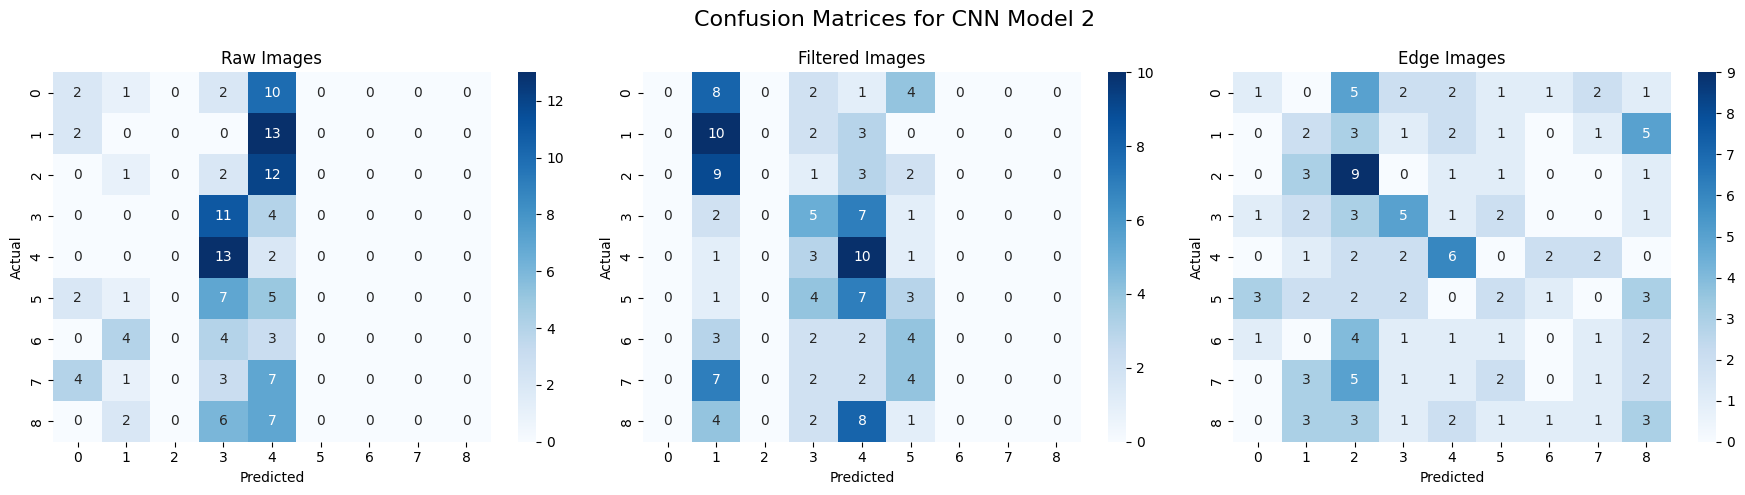

/tmp/ipykernel_1991/2630791101.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=representations, y=scores, palette="viridis")


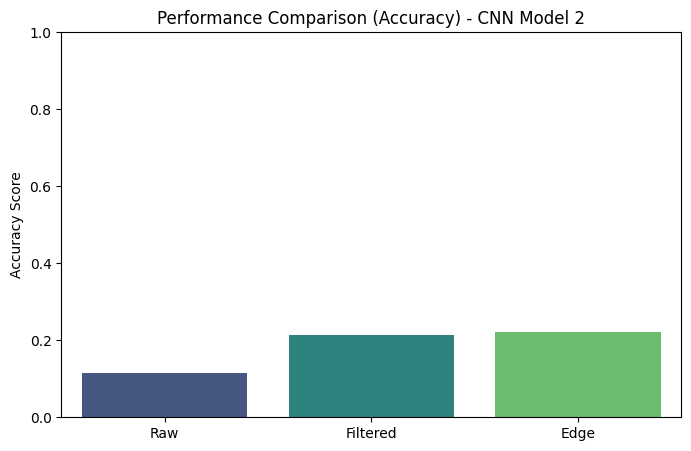

In [75]:
# ============================================
# TASK 6: Visual Comparison (Best Model)
# ============================================

# Dynamically select the best model based on Edge Accuracy
best_model_row = table3_df.loc[table3_df['Accuracy Edge'].idxmax()]
best_model_name = best_model_row['Model']
print(f"Best Performing Model Identified: {best_model_name}")

# Plot Confusion Matrices for the best model across representations
best_preds = predictions_log[best_model_name]
representations = ["Raw", "Filtered", "Edge"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Confusion Matrices for {best_model_name}", fontsize=16)

for i, rep in enumerate(representations):
    cm = confusion_matrix(y_test, best_preds[rep])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=range(len(CLASSES)), yticklabels=range(len(CLASSES)))
    axes[i].set_title(f"{rep} Images")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot Bar Chart for the best model
metrics = ['Accuracy Raw', 'Accuracy Filtered', 'Accuracy Edge']
scores = [best_model_row[m] for m in metrics]

plt.figure(figsize=(8, 5))
sns.barplot(x=representations, y=scores, palette="viridis")
plt.title(f"Performance Comparison (Accuracy) - {best_model_name}")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.0)
plt.show()